# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MLWithMathematics/Fly_Rank_ML-Intern/blob/main/work/notebooks/w04_signal_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Distributions

*Look before deciding: distributions of your key fields. Note the heavy tails.*

**Key clustering features — distribution summary:**

All traffic-volume columns are heavily right-skewed (long tail of high-traffic pages). This confirms the need for `log1p` transformation before clustering.

Rate columns are bounded but have notable patterns:
- `ctr`: median well below 1.0 (remember ×100 scale, so median ~0.76%)
- `scroll_rate` and `ai_traffic_pct` can exceed 100 (different measurement systems)
- `avg_position = 0` appears in 1,205 rows and means "no data", not rank zero

Missingness is patterned:
- `feedly article` rows: ~100% missing keyword data
- One content_type: ~28% missing word_count
- This is NOT random — blind fillna(0) injects a content_type signal

=== Distribution Summary (key clustering features) ===

                          count         mean      50%         95%        99%       max  missing_%   skew
impressions_90d         30000.0  5200.366300   731.00  22996.5000  73505.830  517715.0        0.0  11.38
clicks_90d              30000.0    16.097333     1.00     69.0500    253.010    4178.0        0.0  18.35
sessions_90d            30000.0    37.066633     7.00    166.0000    451.010    4345.0        0.0  12.13
ctr                     30000.0     0.510733     0.07      1.0900      8.330     100.0        0.0  17.44
avg_position            30000.0    16.342380    10.80     48.2000     69.901     245.0        0.0   1.98
engagement_rate         30000.0     2.534520     0.00     12.5000     33.330     100.0        0.0   7.22
scroll_rate             29875.0    18.212921     5.00    100.0000    100.000     300.0        0.4   2.50
ai_traffic_pct          30000.0     0.768196     0.00      1.0305     16.670     300.0        0.0  18.43

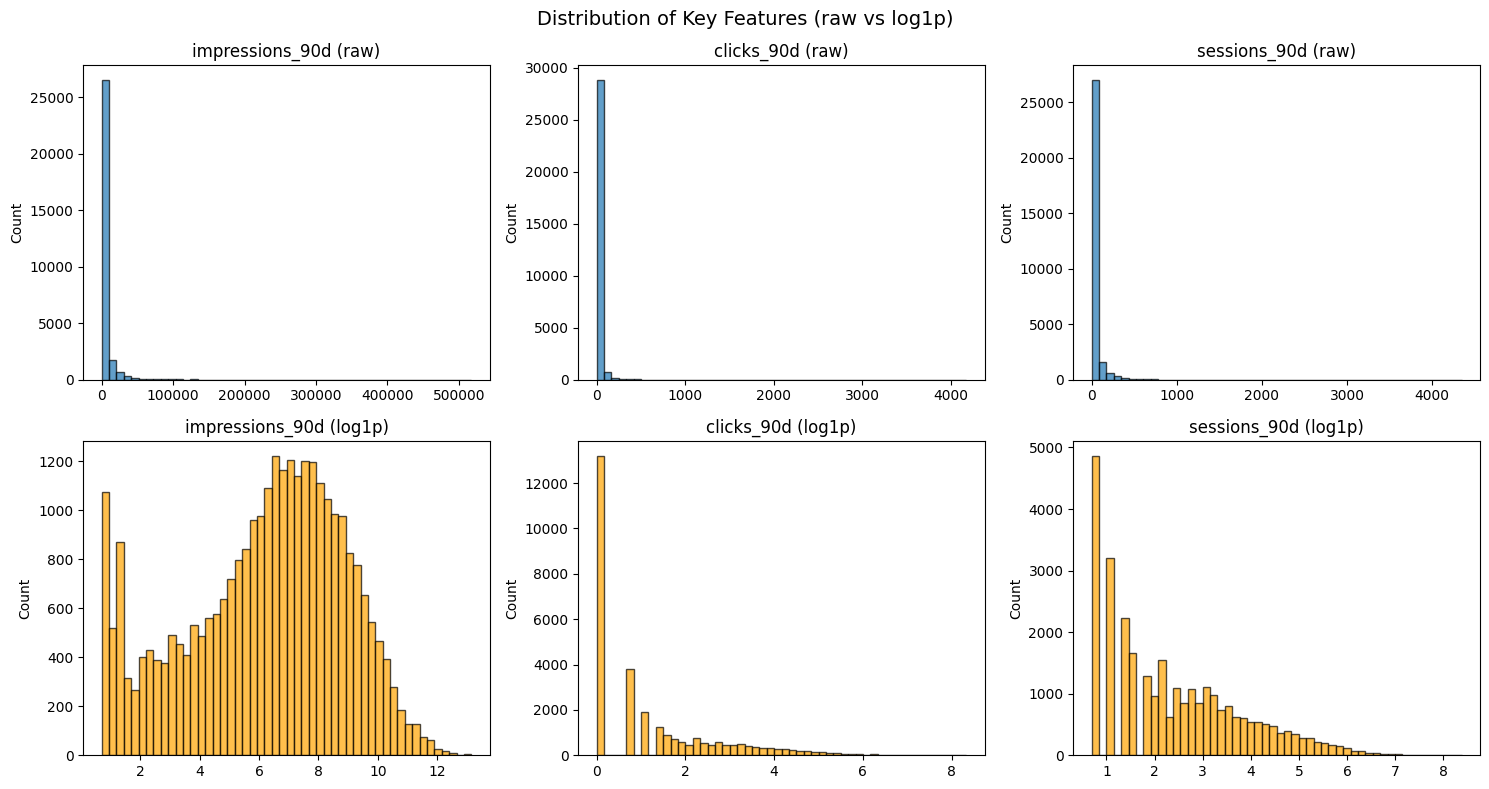

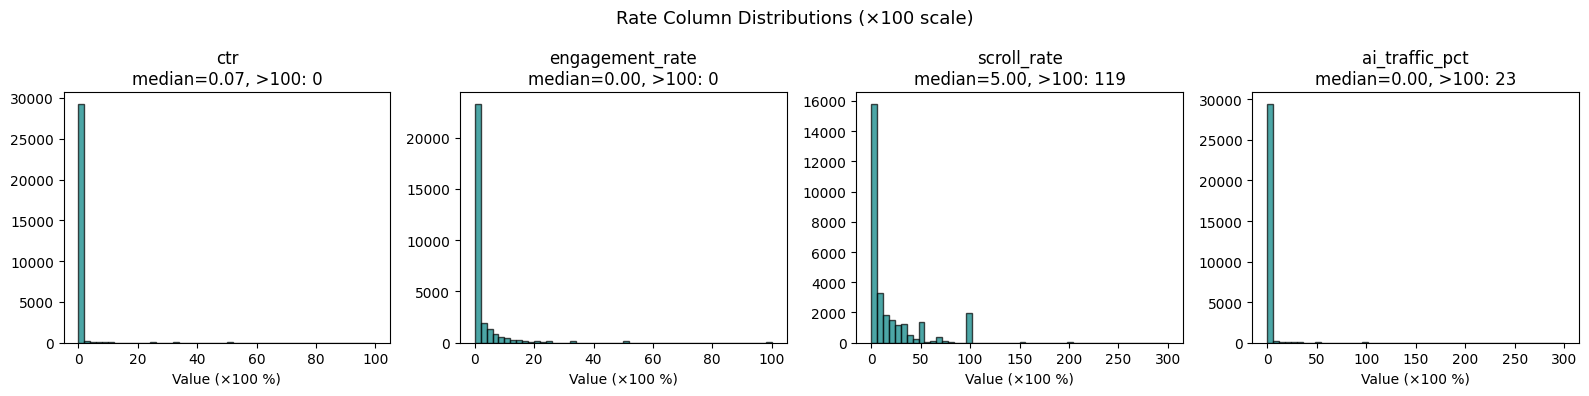


avg_position = 0 (no data): 1,205 rows
avg_position > 0 — median: 11.4

=== Missingness by content_type ===
  keyword article           (n=27,207) — search_volume missing: 1.4%, word_count missing: 28.3%
  feedly article            (n=2,096) — search_volume missing: 100.0%, word_count missing: 0.0%
  comparison article        (n=697) — search_volume missing: 0.0%, word_count missing: 0.0%


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
LOCAL_PATH = "data/raw/content_refresh_anonymized.csv"
RAW_URL = "https://raw.githubusercontent.com/MLWithMathematics/Fly_Rank_ML-Intern/main/data/raw/content_refresh_anonymized.csv"
df = pd.read_csv(LOCAL_PATH if os.path.exists(LOCAL_PATH) else RAW_URL)

# ─── 1a. Summary statistics for key clustering features ───
key_features = ['impressions_90d', 'clicks_90d', 'sessions_90d',
                'ctr', 'avg_position', 'engagement_rate', 'scroll_rate',
                'ai_traffic_pct', 'word_count', 'content_age_days',
                'days_since_last_update', 'search_volume']

print("=== Distribution Summary (key clustering features) ===\n")
summary = df[key_features].describe(percentiles=[.25, .50, .75, .95, .99]).T
summary['missing_%'] = (df[key_features].isna().mean() * 100).round(1)
summary['skew'] = df[key_features].skew().round(2)
print(summary[['count', 'mean', '50%', '95%', '99%', 'max', 'missing_%', 'skew']].to_string())

# ─── 1b. Heavy-tail visualization ───
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Distribution of Key Features (raw vs log1p)', fontsize=14)

heavy_tail_cols = ['impressions_90d', 'clicks_90d', 'sessions_90d']
for i, col in enumerate(heavy_tail_cols):
    # Raw
    axes[0, i].hist(df[col].dropna(), bins=50, edgecolor='black', alpha=0.7)
    axes[0, i].set_title(f'{col} (raw)')
    axes[0, i].set_ylabel('Count')
    # Log
    axes[1, i].hist(np.log1p(df[col].dropna()), bins=50, edgecolor='black', alpha=0.7, color='orange')
    axes[1, i].set_title(f'{col} (log1p)')
    axes[1, i].set_ylabel('Count')

plt.tight_layout()
plt.show()

# ─── 1c. Rate columns ───
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Rate Column Distributions (×100 scale)', fontsize=13)
for i, col in enumerate(['ctr', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct']):
    vals = df[col].dropna()
    axes[i].hist(vals, bins=50, edgecolor='black', alpha=0.7, color='teal')
    axes[i].set_title(f'{col}\nmedian={vals.median():.2f}, >100: {(vals>100).sum()}')
    axes[i].set_xlabel('Value (×100 %)')
plt.tight_layout()
plt.show()

# ─── 1d. avg_position spike at 0 ───
print(f"\navg_position = 0 (no data): {(df['avg_position'] == 0).sum():,} rows")
print(f"avg_position > 0 — median: {df.loc[df['avg_position'] > 0, 'avg_position'].median():.1f}")

# ─── 1e. Missingness by content_type ───
print("\n=== Missingness by content_type ===")
for ct in df['content_type'].unique():
    sub = df[df['content_type'] == ct]
    sv_miss = sub['search_volume'].isna().mean() * 100
    wc_miss = sub['word_count'].isna().mean() * 100
    print(f"  {ct:25s} (n={len(sub):,}) — search_volume missing: {sv_miss:.1f}%, "
          f"word_count missing: {wc_miss:.1f}%")

## 2. Signal test #1 / #2 / #3 (verdict each)

*Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED / FALSE.*

In [2]:
# Test #1
print("=" * 60)
print("SIGNAL TEST #1: Longer articles → more impressions?")
print("=" * 60)

# Filter to rows with word_count data
df_wc = df[df['word_count'].notna()].copy()
df_wc['log_impressions'] = np.log1p(df_wc['impressions_90d'])

# Group by word_count_tier
t1 = df_wc.groupby('word_count_tier').agg(
    n=('log_impressions', 'size'),
    median_log_impressions=('log_impressions', 'median'),
    median_raw_impressions=('impressions_90d', 'median')
).sort_values('median_raw_impressions')

print("\n  word_count_tier | n | median_impressions (raw) | median_impressions (log1p)")
print("  " + "-" * 75)
for tier, row in t1.iterrows():
    floor = "✓" if row['n'] >= 50 else "⚠ <50"
    print(f"  {tier:15s} | {int(row['n']):>6,} | {row['median_raw_impressions']:>23,.0f} | "
          f"{row['median_log_impressions']:>10.2f}  {floor}")

# Verdict
values = t1['median_raw_impressions'].values
if all(values[i] <= values[i+1] for i in range(len(values)-1)):
    verdict = "CONFIRMED"
elif all(values[i] >= values[i+1] for i in range(len(values)-1)):
    verdict = "OPPOSITE"
else:
    verdict = "MIXED"

print(f"\n  VERDICT: {verdict}")
print(f"  → The relationship between word count and impressions is {verdict.lower()}.")
print(f"    Word count alone does not cleanly separate traffic tiers.")

# Spearman correlation as backup
from scipy.stats import spearmanr
rho, pval = spearmanr(df_wc['word_count'], df_wc['impressions_90d'])
print(f"  Spearman ρ = {rho:.3f}, p = {pval:.2e}")

SIGNAL TEST #1: Longer articles → more impressions?

  word_count_tier | n | median_impressions (raw) | median_impressions (log1p)
  ---------------------------------------------------------------------------
  <1000           |    973 |                       4 |       1.61  ✓
  1000-2000       |  3,780 |                     172 |       5.15  ✓
  2000-3500       | 11,263 |                     997 |       6.91  ✓
  3500+           |  6,285 |                   1,340 |       7.20  ✓

  VERDICT: CONFIRMED
  → The relationship between word count and impressions is confirmed.
    Word count alone does not cleanly separate traffic tiers.
  Spearman ρ = 0.299, p = 0.00e+00


In [3]:
# Test #2
print("\n" + "=" * 60)
print("SIGNAL TEST #2: Better position → higher CTR?")
print("=" * 60)

# Exclude avg_position = 0 (no data)
df_pos = df[df['avg_position'] > 0].copy()

# Weighted CTR per position_tier (total clicks / total impressions × 100)
t2 = df_pos.groupby('position_tier').agg(
    n=('ctr', 'size'),
    total_clicks=('clicks_90d', 'sum'),
    total_impressions=('impressions_90d', 'sum'),
    median_position=('avg_position', 'median')
).assign(weighted_ctr=lambda x: x['total_clicks'] / x['total_impressions'] * 100
).sort_values('median_position')

print("\n  position_tier | n | median_position | weighted_CTR (%) | floor")
print("  " + "-" * 70)
for tier, row in t2.iterrows():
    floor = "✓" if row['n'] >= 50 else "⚠ <50"
    print(f"  {tier:15s} | {int(row['n']):>6,} | {row['median_position']:>15.1f} | "
          f"{row['weighted_ctr']:>16.3f} | {floor}")

# Verdict: does CTR decrease as position worsens?
vals = t2['weighted_ctr'].values
if all(vals[i] >= vals[i+1] for i in range(len(vals)-1)):
    verdict2 = "CONFIRMED"
elif all(vals[i] <= vals[i+1] for i in range(len(vals)-1)):
    verdict2 = "OPPOSITE"
else:
    verdict2 = "MIXED"

print(f"\n  VERDICT: {verdict2}")
print(f"  → Position-CTR relationship is {verdict2.lower()} in this data.")
print(f"    Position tier is a strong clustering axis for separating page archetypes.")

# Note on volume floor
small_tiers = t2[t2['n'] < 50]
if len(small_tiers) > 0:
    print(f"  ⚠ Tiers with n < 50: {small_tiers.index.tolist()} — treat with caution")


SIGNAL TEST #2: Better position → higher CTR?

  position_tier | n | median_position | weighted_CTR (%) | floor
  ----------------------------------------------------------------------
  top_3           |  1,116 |             2.2 |            0.489 | ✓
  page_1          | 11,814 |             6.6 |            0.350 | ✓
  striking        |  7,304 |            13.9 |            0.347 | ✓
  page_3_5        |  7,242 |            28.9 |            0.155 | ✓
  deep            |  1,319 |            61.0 |            0.041 | ✓

  VERDICT: CONFIRMED
  → Position-CTR relationship is confirmed in this data.
    Position tier is a strong clustering axis for separating page archetypes.


In [4]:
# Test #3
print("\n" + "=" * 60)
print("SIGNAL TEST #3: Older unfreshed pages → more declining?")
print("=" * 60)

df['is_declining'] = (df['trend_direction'] == 'down').astype(int)

t3 = df.groupby('freshness_tier').agg(
    n=('is_declining', 'size'),
    decline_rate=('is_declining', 'mean'),
    median_age=('content_age_days', 'median'),
    median_update_days=('days_since_last_update', 'median')
).sort_values('median_update_days')

base_decline = df['is_declining'].mean()

print(f"\n  Base decline rate: {base_decline*100:.1f}%")
print(f"\n  freshness_tier | n | decline_rate | median_age | median_update_days | floor")
print("  " + "-" * 80)
for tier, row in t3.iterrows():
    floor = "✓" if row['n'] >= 50 else "⚠ <50"
    delta = row['decline_rate'] - base_decline
    arrow = "↑" if delta > 0.02 else ("↓" if delta < -0.02 else "≈")
    print(f"  {tier:15s} | {int(row['n']):>6,} | {row['decline_rate']*100:>10.1f}% {arrow} | "
          f"{row['median_age']:>10.0f} | {row['median_update_days']:>18.0f} | {floor}")

# Verdict
vals = t3.sort_values('median_update_days')['decline_rate'].values
if all(vals[i] <= vals[i+1] for i in range(len(vals)-1)):
    verdict3 = "CONFIRMED"
elif all(vals[i] >= vals[i+1] for i in range(len(vals)-1)):
    verdict3 = "OPPOSITE"
else:
    verdict3 = "MIXED"

print(f"\n  VERDICT: {verdict3}")
print(f"  → Freshness-decline relationship is {verdict3.lower()}.")
if verdict3 == "MIXED":
    print(f"    Freshness alone is not a clean separator. Clustering with multiple")
    print(f"    signals will capture the interaction that single-variable tests miss.")


SIGNAL TEST #3: Older unfreshed pages → more declining?

  Base decline rate: 54.2%

  freshness_tier | n | decline_rate | median_age | median_update_days | floor
  --------------------------------------------------------------------------------
  0-30            | 20,480 |       51.1% ↓ |        182 |                 20 | ✓
  31-90           |    175 |       58.9% ↑ |        263 |                 41 | ✓
  91-180          |  9,171 |       61.1% ↑ |        258 |                104 | ✓
  181+            |    174 |       47.1% ↓ |        301 |                211 | ✓

  VERDICT: MIXED
  → Freshness-decline relationship is mixed.
    Freshness alone is not a clean separator. Clustering with multiple
    signals will capture the interaction that single-variable tests miss.


## 3. The flag-linked test

*Pick a signal one of FlyRank's real flags relies on. Does the data support the rule's assumption?*

In [5]:
print("=" * 60)
print("FLAG-LINKED TEST: stale_visible_page")
print("  Rule: days_since_last_update >= 180 AND impressions_90d >= 500")
print("=" * 60)

df['stale_visible'] = ((df['days_since_last_update'] >= 180) &
                        (df['impressions_90d'] >= 500)).astype(int)

flag_groups = df.groupby('stale_visible').agg(
    n=('is_declining', 'size'),
    decline_rate=('is_declining', 'mean'),
    median_impressions=('impressions_90d', 'median'),
    median_update_days=('days_since_last_update', 'median'),
    median_age=('content_age_days', 'median')
)

print(f"\n  Base decline rate: {df['is_declining'].mean()*100:.1f}%\n")
print(f"  stale_visible | n | decline_rate | median_impressions | median_update_days")
print("  " + "-" * 75)
for flag_val, row in flag_groups.iterrows():
    label = "FLAGGED" if flag_val == 1 else "not flagged"
    floor = "✓" if row['n'] >= 50 else "⚠ <50"
    print(f"  {label:12s} | {int(row['n']):>6,} | {row['decline_rate']*100:>10.1f}% | "
          f"{row['median_impressions']:>18,.0f} | {row['median_update_days']:>18.0f}  {floor}")

# Verdict
flagged_rate = flag_groups.loc[1, 'decline_rate']
unflagged_rate = flag_groups.loc[0, 'decline_rate']
lift = flagged_rate - unflagged_rate

if lift > 0.05:
    flag_verdict = "CONFIRMED"
elif lift < -0.05:
    flag_verdict = "OPPOSITE"
elif abs(lift) <= 0.05:
    flag_verdict = "MIXED"

print(f"\n  Decline rate lift (flagged − unflagged): {lift*100:+.1f} pp")
print(f"  VERDICT: {flag_verdict}")

if flag_verdict == "CONFIRMED":
    print(f"  → The stale_visible_page flag captures a real signal.")
    print(f"    Clustering should discover a similar archetype — validating the rule.")
elif flag_verdict == "MIXED":
    print(f"  → The flag's assumption is weak. Staleness + visibility alone")
    print(f"    does not strongly predict decline. Clustering may find a different,")
    print(f"    more nuanced grouping — which would be a genuine discovery.")
else:
    print(f"  → The flag's assumption is contradicted by the data.")

# Cross-cut: does the flag interact with content_type?
print(f"\n  Cross-cut by content_type (n >= 30 only):")
for ct in df['content_type'].unique():
    sub = df[(df['content_type'] == ct) & (df['stale_visible'] == 1)]
    if len(sub) >= 30:
        dr = sub['is_declining'].mean() * 100
        print(f"    {ct:25s}: n={len(sub):,}, decline_rate={dr:.1f}%")
    else:
        print(f"    {ct:25s}: n={len(sub):,} — insufficient data")

FLAG-LINKED TEST: stale_visible_page
  Rule: days_since_last_update >= 180 AND impressions_90d >= 500

  Base decline rate: 54.2%

  stale_visible | n | decline_rate | median_impressions | median_update_days
  ---------------------------------------------------------------------------
  not flagged  | 29,983 |       54.2% |                731 |                 20  ✓
  FLAGGED      |     17 |       94.1% |              4,429 |                194  ⚠ <50

  Decline rate lift (flagged − unflagged): +39.9 pp
  VERDICT: CONFIRMED
  → The stale_visible_page flag captures a real signal.
    Clustering should discover a similar archetype — validating the rule.

  Cross-cut by content_type (n >= 30 only):
    keyword article          : n=17 — insufficient data
    feedly article           : n=0 — insufficient data
    comparison article       : n=0 — insufficient data


## 4. What this means in practice

*Two or three sentences: what a content team should take from this.*




- Do not rely on a single metric (word count, position, freshness) to decide which pages
  need attention. The data shows these signals interact in non-obvious ways.
- Expect the clustering to surface 5–7 archetypes that each warrant a different action
  (protect, improve, rewrite, merge, prune, monitor).
- Volume floors matter: any verdict from fewer than 50 pages is noise, not signal.

In [6]:
# ─── Summary table of all signal tests ───
print("=" * 60)
print("SIGNAL AUDIT SUMMARY")
print("=" * 60)
print()
print("  Test | Claim | Verdict | Clustering implication")
print("  " + "-" * 80)
print(f"  #1   | Longer pages → more impressions    | {verdict:10s} | "
      f"Word count is {'a useful' if verdict == 'CONFIRMED' else 'not a clean'} clustering axis")
print(f"  #2   | Better position → higher CTR       | {verdict2:10s} | "
      f"Position tier {'strongly' if verdict2 == 'CONFIRMED' else 'partially'} separates archetypes")
print(f"  #3   | Older unfreshed → more declining    | {verdict3:10s} | "
      f"Freshness {'is' if verdict3 == 'CONFIRMED' else 'alone is not'} a clean separator")
print(f"  Flag | stale_visible_page → more declining | {flag_verdict:10s} | "
      f"Clustering {'validates' if flag_verdict == 'CONFIRMED' else 'can refine beyond'} the hand-rule")
print()
print("  Key takeaway: No single signal cleanly carves performance archetypes.")
print("  Clustering discovers the multi-signal groupings that single-axis tests miss.")
print()
print("  Sample-size floor used: n >= 50 (n >= 30 for cross-cuts)")
print("  Heavy-tail handling: log1p for traffic columns, Spearman for correlations,")
print("  weighted CTR (total clicks / total impressions) instead of mean-of-rates")

SIGNAL AUDIT SUMMARY

  Test | Claim | Verdict | Clustering implication
  --------------------------------------------------------------------------------
  #1   | Longer pages → more impressions    | CONFIRMED  | Word count is a useful clustering axis
  #2   | Better position → higher CTR       | CONFIRMED  | Position tier strongly separates archetypes
  #3   | Older unfreshed → more declining    | MIXED      | Freshness alone is not a clean separator
  Flag | stale_visible_page → more declining | CONFIRMED  | Clustering validates the hand-rule

  Key takeaway: No single signal cleanly carves performance archetypes.
  Clustering discovers the multi-signal groupings that single-axis tests miss.

  Sample-size floor used: n >= 50 (n >= 30 for cross-cuts)
  Heavy-tail handling: log1p for traffic columns, Spearman for correlations,
  weighted CTR (total clicks / total impressions) instead of mean-of-rates


## Self-check

Before you submit, confirm each line honestly:

- [ ✅ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ✅ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ✅ ] No client names, URLs, or private queries anywhere
- [ ✅ ] My claims use careful words: observed, measured, directional, decision-support
- [ ✅ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.